# Relacion entre atributos con UCI Student Performance

Este notebook descarga el conjunto **Student Performance** desde `ucimlrepo` y prueba las funciones de `src.preprocessing`.

Se estudian:
- correlaciones Pearson y Spearman entre variables numericas;
- asociaciones Cramer entre variables categoricas;
- relacion de las variables con objetivos numerico y categorico;
- pares de variables con asociaciones fuertes o aparentemente debiles;
- graficos configurables y matrices reutilizables.

In [1]:
# Ejecutar una vez si faltan dependencias en el entorno del notebook.
%pip install ucimlrepo pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Permite importar src aunque el notebook se ejecute desde otra carpeta.
project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.preprocessing import (
    cramers_v,
    get_boundaries_iqr,
    get_categorical_columns,
    get_categorical_target_associations,
    get_cramers_v_matrix,
    get_numeric_columns,
    get_numeric_correlation_matrix,
    get_numeric_target_correlations,
    get_top_numeric_correlations,
    plot_categorical_countplots,
    plot_correlation_heatmap,
    plot_cramers_v_heatmap,
    plot_numeric_boxplots,
    plot_numeric_boxplots_by_target,
    plot_numeric_histograms,
)

pd.set_option('display.max_columns', 100)

## 1. Descargar y preparar los datos

In [3]:
student_performance = fetch_ucirepo(id=320)
df = student_performance.data.features.copy()
df['G3'] = student_performance.data.targets['G3']

# Objetivo categorico derivado: aprobado si la calificacion final es al menos 10.
df['passed'] = (df['G3'] >= 10).astype('category')

print(f'Filas: {df.shape[0]}, columnas: {df.shape[1]}')
display(df.head())
display(df.dtypes.to_frame('dtype'))

Filas: 649, columnas: 32


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G3,passed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,11,True
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,11,True
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,True
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,True
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,13,True


,dtype
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


## 2. Identificar tipos y revisar outliers

In [4]:
numeric_columns = get_numeric_columns(df)
categorical_columns = get_categorical_columns(df)

print('Columnas numericas:', numeric_columns)
print('Columnas categoricas:', categorical_columns)

iqr_boundaries = {
    column: get_boundaries_iqr(df[column])
    for column in numeric_columns
}
display(pd.DataFrame(iqr_boundaries, index=['lower_bound', 'upper_bound']).T)

Columnas numericas: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G3']
Columnas categoricas: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'passed']


,lower_bound,upper_bound
age,13.0,21.0
Medu,-1.0,7.0
Fedu,-2.0,6.0
traveltime,-0.5,3.5
studytime,-0.5,3.5
failures,0.0,0.0
famrel,2.5,6.5
freetime,1.5,5.5
goout,-1.0,7.0
Dalc,-0.5,3.5


## 3. Correlaciones numericas

Las matrices se conservan en variables para poder filtrarlas, exportarlas o usarlas en otros analisis.

In [5]:
pearson_matrix = get_numeric_correlation_matrix(df, numeric_columns, method='pearson')
spearman_matrix = get_numeric_correlation_matrix(df, numeric_columns, method='spearman')

print('Matriz Pearson')
display(pearson_matrix.round(3))
print('Matriz Spearman')
display(spearman_matrix.round(3))

top_pearson = get_top_numeric_correlations(pearson_matrix, threshold=0.30, top_n=15)
top_spearman = get_top_numeric_correlations(spearman_matrix, threshold=0.30, top_n=15)
print('Relaciones numericas mas relevantes - Pearson')
display(top_pearson)
print('Relaciones numericas mas relevantes - Spearman')
display(top_spearman)

Matriz Pearson


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G3
age,1.000,-0.108,-0.121,0.034,-0.008,0.320,-0.021,-0.005,0.113,0.135,0.086,-0.009,0.150,-0.107
Medu,-0.108,1.000,0.647,-0.265,0.097,-0.172,0.024,-0.020,0.010,-0.007,-0.020,0.005,-0.009,0.240
Fedu,-0.121,0.647,1.000,-0.208,0.050,-0.166,0.020,0.007,0.028,0.000,0.038,0.045,0.030,0.212
traveltime,0.034,-0.265,-0.208,1.000,-0.063,0.098,-0.010,0.001,0.057,0.093,0.057,-0.048,-0.008,-0.127
studytime,-0.008,0.097,0.050,-0.063,1.000,-0.147,-0.004,-0.069,-0.075,-0.138,-0.215,-0.056,-0.118,0.250
failures,0.320,-0.172,-0.166,0.098,-0.147,1.000,-0.063,0.109,0.045,0.106,0.082,0.036,0.123,-0.393
famrel,-0.021,0.024,0.020,-0.010,-0.004,-0.063,1.000,0.129,0.090,-0.076,-0.094,0.110,-0.090,0.063
freetime,-0.005,-0.020,0.007,0.001,-0.069,0.109,0.129,1.000,0.346,0.110,0.120,0.085,-0.019,-0.123
goout,0.113,0.010,0.028,0.057,-0.075,0.045,0.090,0.346,1.000,0.245,0.389,-0.016,0.085,-0.088
Dalc,0.135,-0.007,0.000,0.093,-0.138,0.106,-0.076,0.110,0.245,1.000,0.617,0.059,0.173,-0.205


Matriz Spearman


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G3
age,1.000,-0.102,-0.110,0.067,0.017,0.291,-0.019,-0.010,0.131,0.081,0.094,-0.018,0.124,-0.066
Medu,-0.102,1.000,0.647,-0.263,0.098,-0.208,0.025,-0.028,0.010,0.002,-0.018,0.016,-0.006,0.284
Fedu,-0.110,0.647,1.000,-0.222,0.069,-0.161,0.021,-0.000,0.029,-0.005,0.030,0.046,0.032,0.235
traveltime,0.067,-0.263,-0.222,1.000,-0.089,0.124,-0.026,-0.001,0.041,0.068,0.032,-0.064,0.023,-0.147
studytime,0.017,0.098,0.069,-0.089,1.000,-0.160,0.019,-0.076,-0.082,-0.171,-0.222,-0.077,-0.117,0.275
failures,0.291,-0.208,-0.161,0.124,-0.160,1.000,-0.059,0.100,0.042,0.109,0.065,0.041,0.121,-0.448
famrel,-0.019,0.025,0.021,-0.026,0.019,-0.059,1.000,0.144,0.088,-0.098,-0.102,0.093,-0.104,0.048
freetime,-0.010,-0.028,-0.000,-0.001,-0.076,0.100,0.144,1.000,0.354,0.127,0.120,0.095,-0.028,-0.128
goout,0.131,0.010,0.029,0.041,-0.082,0.042,0.088,0.354,1.000,0.234,0.372,-0.012,0.104,-0.105
Dalc,0.081,0.002,-0.005,0.068,-0.171,0.109,-0.098,0.127,0.234,1.000,0.613,0.085,0.104,-0.208


Relaciones numericas mas relevantes - Pearson


,variable_1,variable_2,correlation,absolute_correlation
0,Medu,Fedu,0.647477,0.647477
1,Dalc,Walc,0.616561,0.616561
2,failures,G3,-0.393316,0.393316
3,goout,Walc,0.388680,0.388680
4,freetime,goout,0.346352,0.346352
5,age,failures,0.319968,0.319968


Relaciones numericas mas relevantes - Spearman


,variable_1,variable_2,correlation,absolute_correlation
0,Medu,Fedu,0.647194,0.647194
1,Dalc,Walc,0.613056,0.613056
2,failures,G3,-0.448360,0.448360
3,goout,Walc,0.372455,0.372455
4,freetime,goout,0.354345,0.354345


In [6]:
# Comparar la relacion de los atributos con el objetivo numerico G3.
g3_pearson = get_numeric_target_correlations(df, target='G3', method='pearson')
g3_spearman = get_numeric_target_correlations(df, target='G3', method='spearman')

display(pd.concat({'pearson': g3_pearson, 'spearman': g3_spearman}, axis=1).round(3))

# Pares aparentemente independientes segun Pearson: revisar siempre con graficos.
weak_pairs = get_top_numeric_correlations(pearson_matrix, threshold=0.0)
weak_pairs = weak_pairs[weak_pairs['absolute_correlation'] < 0.10]
display(weak_pairs)

,pearson,spearman
failures,-0.393,-0.448
studytime,0.250,0.275
Medu,0.240,0.284
Fedu,0.212,0.235
Dalc,-0.205,-0.208
Walc,-0.177,-0.171
traveltime,-0.127,-0.147
freetime,-0.123,-0.128
age,-0.107,-0.066
health,-0.099,-0.106


,variable_1,variable_2,correlation,absolute_correlation
38,health,G3,-0.098851,0.098851
39,traveltime,failures,0.097730,0.097730
40,Medu,studytime,0.097006,0.097006
41,famrel,Walc,-0.093511,0.093511
42,traveltime,Dalc,0.092824,0.092824
43,absences,G3,-0.091379,0.091379
44,famrel,goout,0.089707,0.089707
45,famrel,absences,-0.089534,0.089534
46,goout,G3,-0.087641,0.087641
47,age,Walc,0.086357,0.086357


## 4. Asociaciones categoricas

Cramer V mide la intensidad de la asociacion, no su direccion.

In [7]:
categorical_analysis_columns = categorical_columns[:8]
cramers_matrix = get_cramers_v_matrix(
    df,
    categorical_columns=categorical_analysis_columns,
    max_vars=None
)

print('Matriz Cramer V')
display(cramers_matrix.round(3))

categorical_target_associations = get_categorical_target_associations(
    df,
    target='passed',
    categorical_columns=categorical_columns
)
print('Asociacion con el objetivo categorico passed')
display(categorical_target_associations.round(3))

print('Ejemplo de Cramer V entre dos columnas')
print(cramers_v(df['school'], df['passed']))

Matriz Cramer V


,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason
school,0.997,0.080,0.351,0.019,0.023,0.242,0.181,0.284
sex,0.080,0.997,0.022,0.095,0.060,0.168,0.082,0.076
address,0.351,0.022,0.996,0.042,0.090,0.205,0.091,0.172
famsize,0.019,0.095,0.042,0.996,0.234,0.063,0.087,0.067
Pstatus,0.023,0.060,0.090,0.234,0.993,0.063,0.098,0.070
Mjob,0.242,0.168,0.205,0.063,0.063,1.000,0.228,0.124
Fjob,0.181,0.082,0.091,0.087,0.098,0.228,1.000,0.102
reason,0.284,0.076,0.172,0.067,0.070,0.124,0.102,1.000


Asociacion con el objetivo categorico passed


higher        0.303
school        0.293
reason        0.166
Mjob          0.123
address       0.122
guardian      0.084
internet      0.083
romantic      0.077
sex           0.074
Fjob          0.065
famsize       0.048
paid          0.045
activities    0.043
famsup        0.034
schoolsup     0.028
nursery       0.002
Pstatus       0.000
Name: cramers_v, dtype: float64

Ejemplo de Cramer V entre dos columnas
0.29273786438170696


## 5. Graficos configurables

Se usan pocas columnas en algunos graficos para que el notebook sea rapido de inspeccionar. Los parametros `annot`, `cbar`, `fmt` y las mascaras se pueden cambiar.

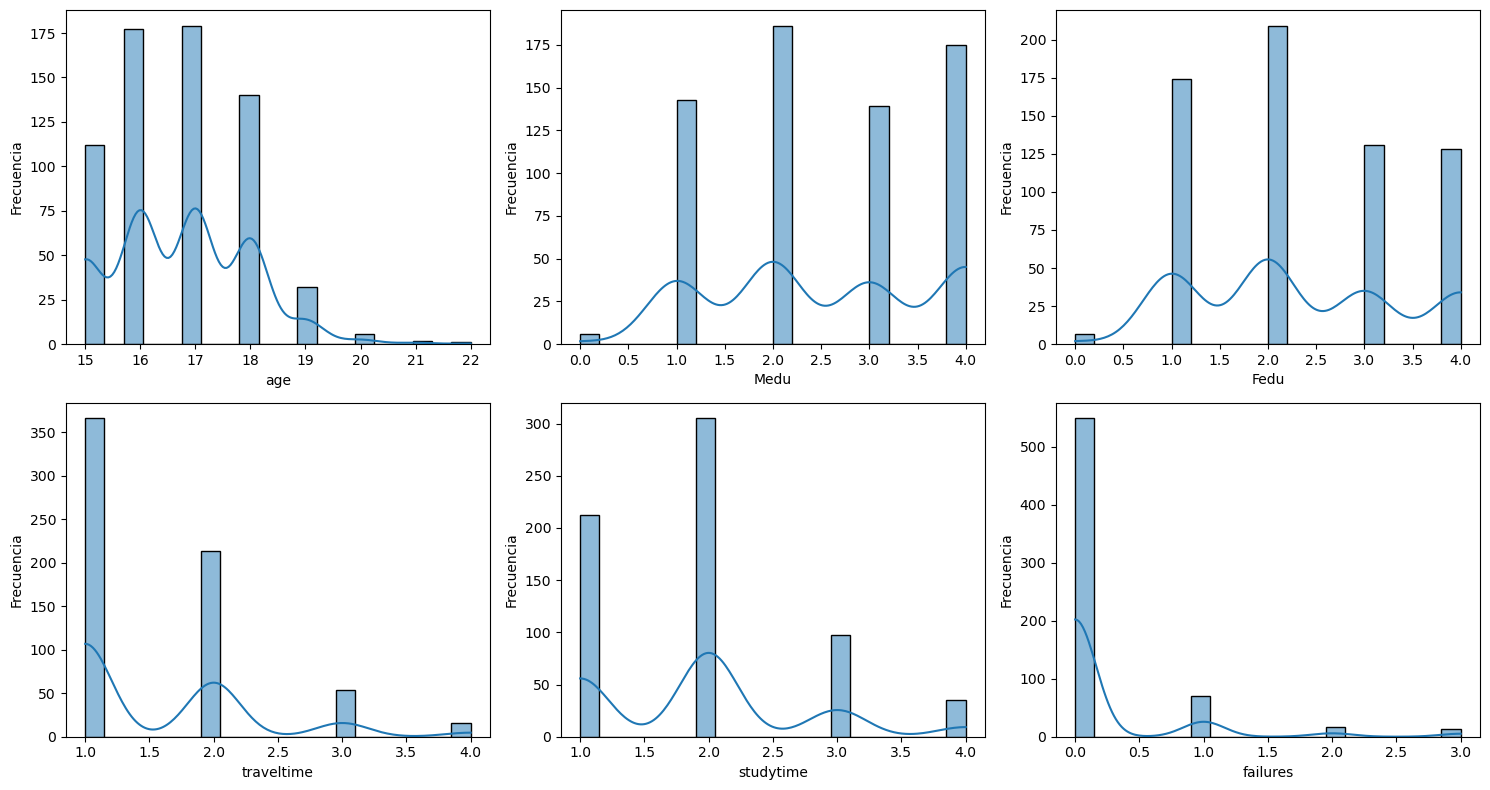

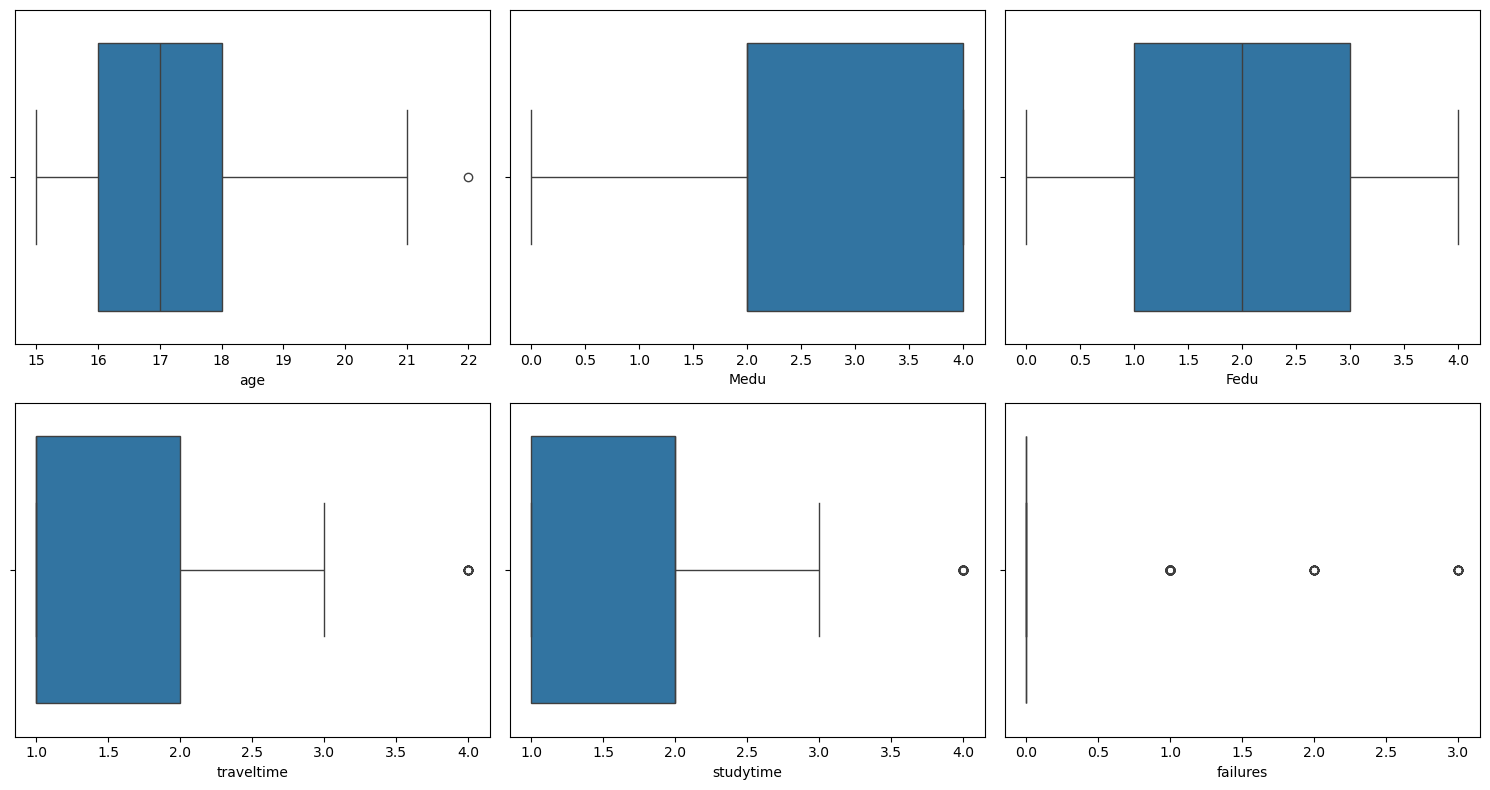

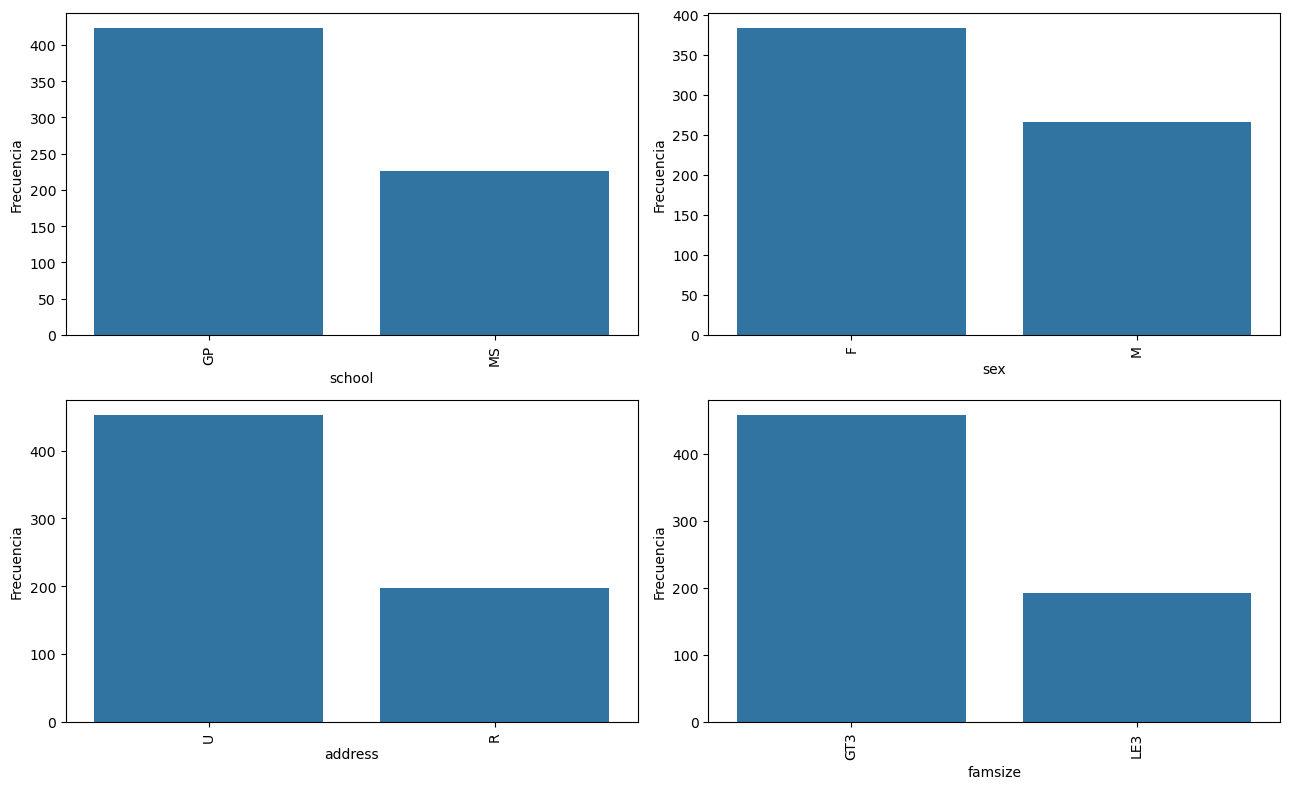

In [8]:
plot_numeric_histograms(df, numeric_columns[:6], fig_per_row=3, bins=20, kde=True)
plot_numeric_boxplots(df, numeric_columns[:6], fig_per_row=3)
plot_categorical_countplots(df, categorical_columns[:4], fig_per_row=2, top_n=8)

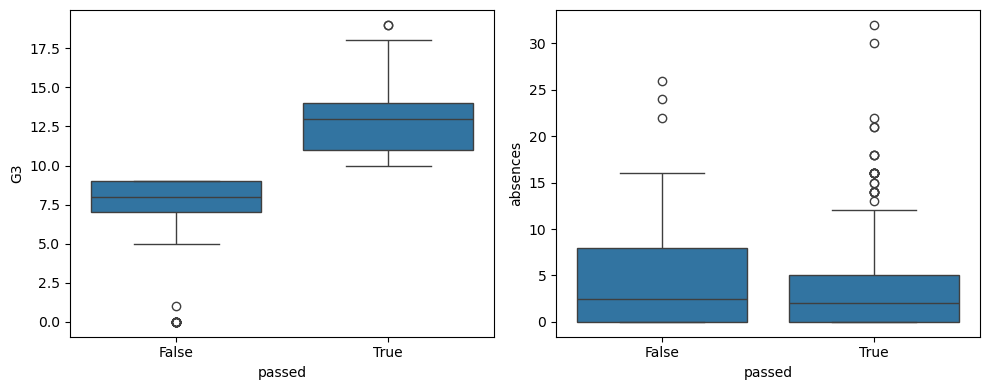

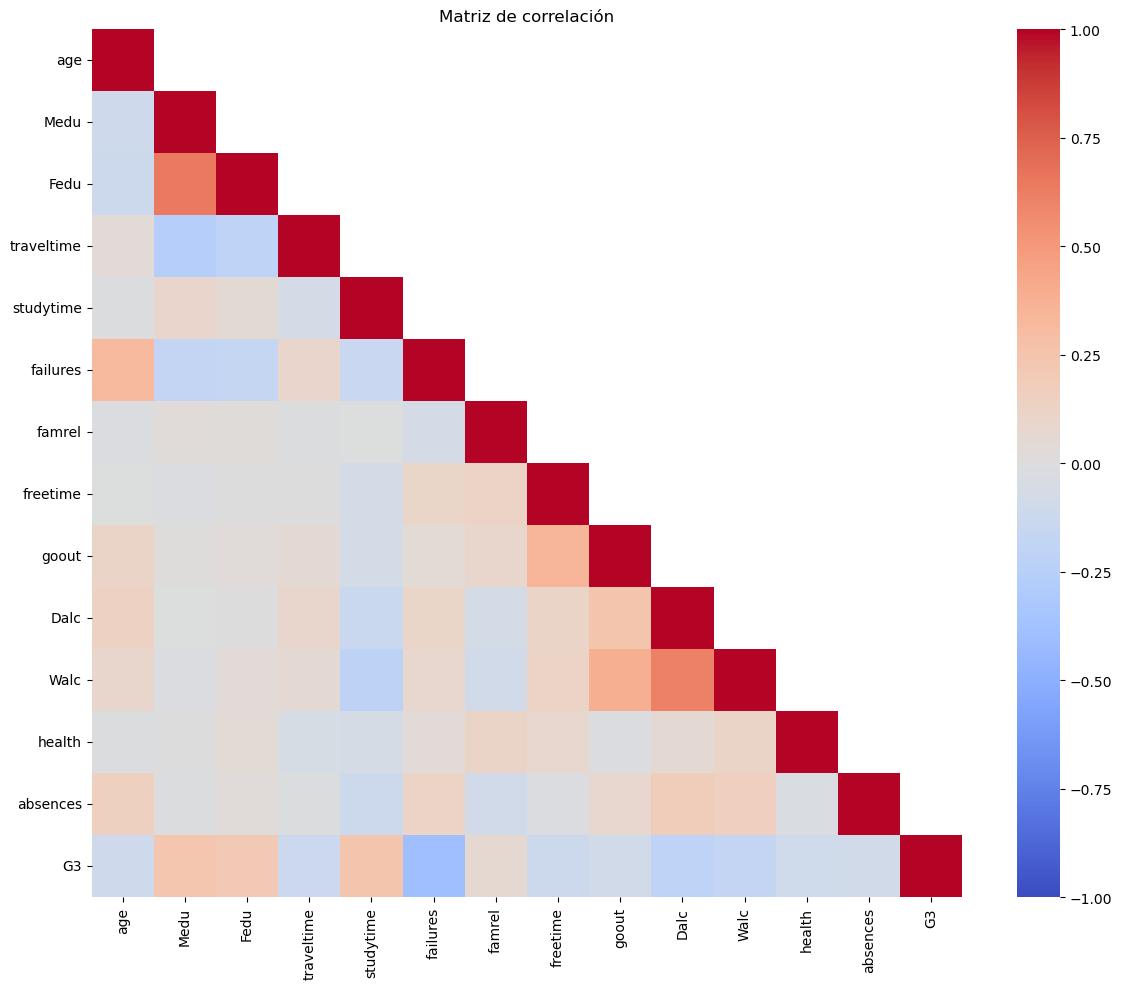

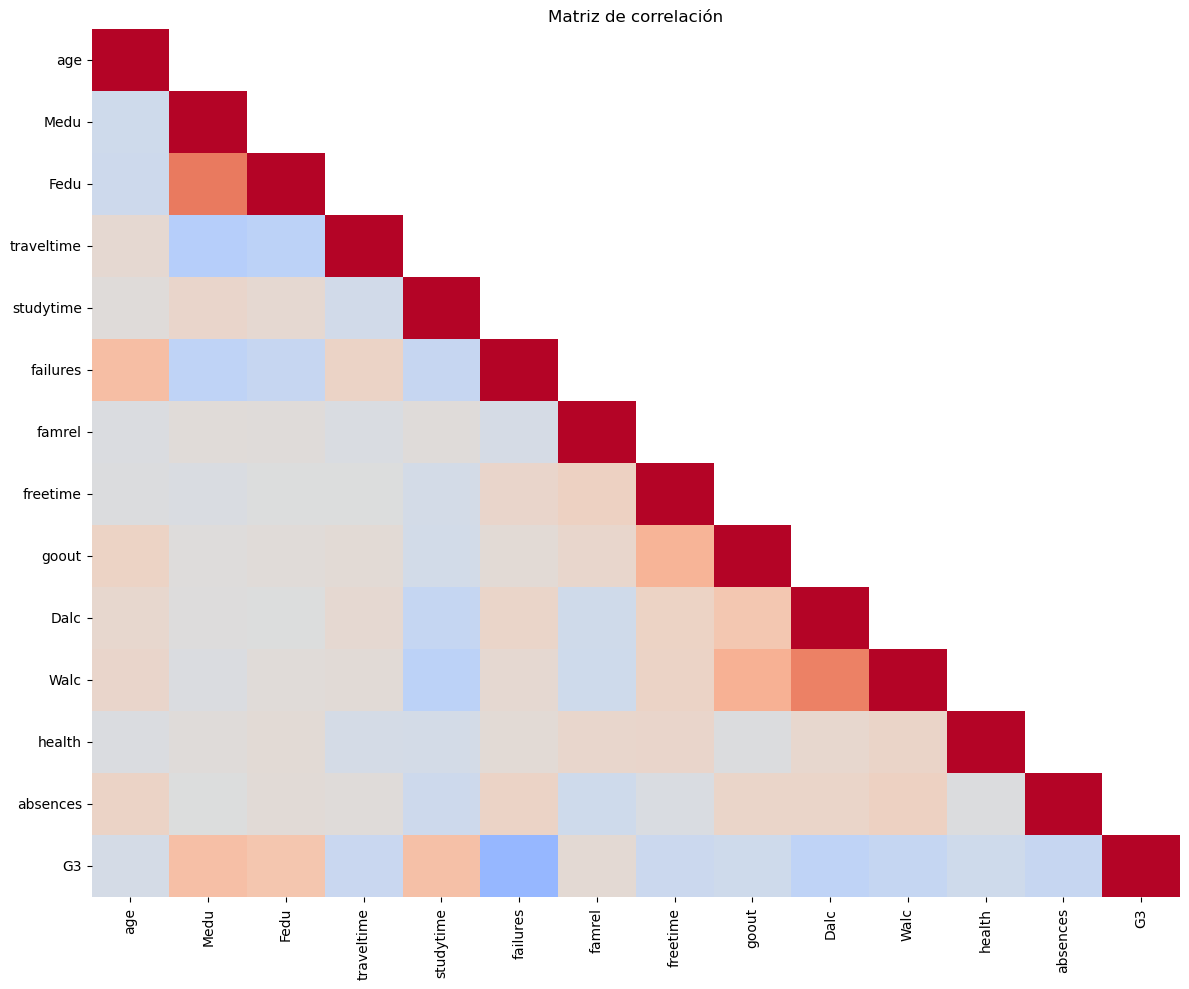

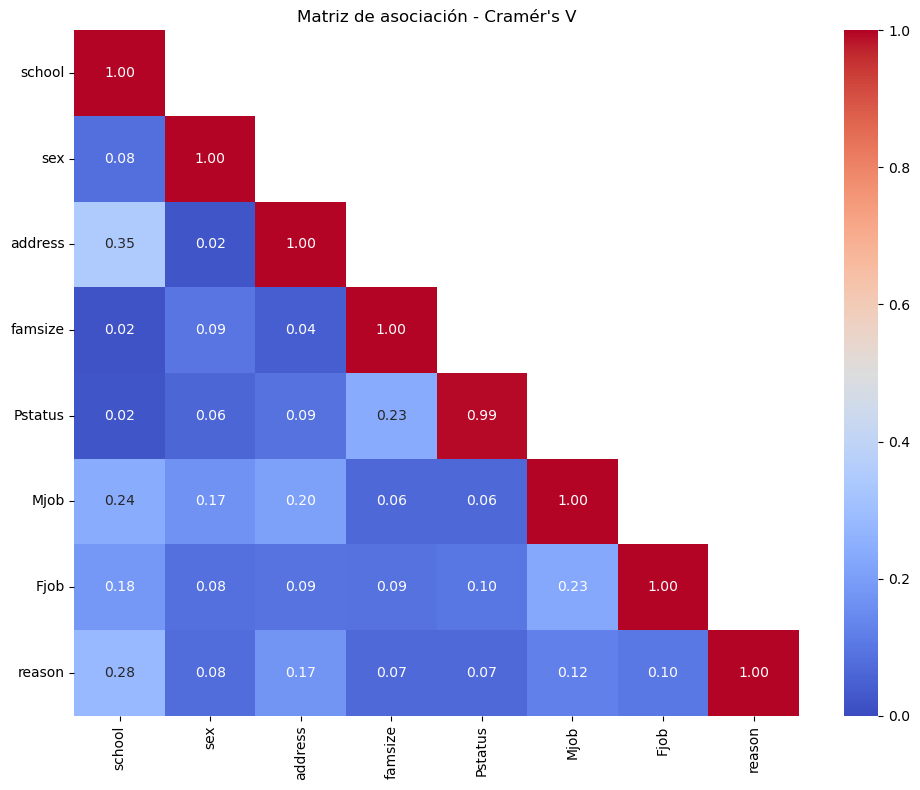

In [9]:
plot_numeric_boxplots_by_target(
    df,
    target='passed',
    numeric_columns=['G3', 'absences'],
    fig_per_row=2
)

plot_correlation_heatmap(
    pearson_matrix,
    figsize=(12, 10),
    annot=False,
    cbar=True,
    mask_upper_triangle=True
)

plot_correlation_heatmap(
    spearman_matrix,
    figsize=(12, 10),
    annot=False,
    cbar=False,
    mask_upper_triangle=True
)

plot_cramers_v_heatmap(
    cramers_matrix,
    figsize=(10, 8),
    annot=True,
    cbar=True,
    lower_triangle_only=True
)

## 6. Exportar matrices para continuar el analisis

Estas lineas son opcionales. Las matrices ya estan disponibles en memoria y tambien se pueden guardar como CSV.

In [11]:
pearson_matrix.to_csv('data/pearson_matrix.csv')
spearman_matrix.to_csv('data/spearman_matrix.csv')
cramers_matrix.to_csv('data/cramers_v_matrix.csv')
print('Matrices exportadas correctamente.')

Matrices exportadas correctamente.
